In [ ]:
!pip install -U classiq
!pip install keyrings.alt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.1/657.1 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 1.3 MB/s eta 0:00:00
  Attempting uninstall: zstandard
    Found existing installation: zstandard 0.25.0
    Uninstalling zstandard-0.25.0:
      Successfully uninstalled zstandard-0.25.0
  Attempting uninstall: pyomo
    Found existing installation: pyomo 6.10.0
    Uninstalling pyomo-6.10.0:
      Successfully 

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
^C


In [ ]:
import keyring
from keyrings.alt.file import PlaintextKeyring
keyring.set_keyring(PlaintextKeyring())

In [ ]:
import classiq
classiq.authenticate(overwrite=True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from tabulate import tabulate

from classiq import *

In [ ]:
# Inputs
n = 2  # dimension of vectors x(0) and b
t = 1
M = np.array([[0, 1], [-1, 0]])
x_0 = [1, 1]
b = [0, 0]

# Constants
k = 7
x_0_norm = np.linalg.norm(x_0)
b_norm = np.linalg.norm(b)
M_norm = np.linalg.norm(M)
# A = np.multiply(1/np.linalg.norm(M), M)
A = M

In [ ]:
vs1 = []
c = 0


def VS1(t):
    global vs1
    global c
    c = 0
    c_m = np.zeros(k + 1)
    m_factorial = 1
    for i in range(k + 1):
        c_m[i] = (x_0_norm * (pow(t, i))) / m_factorial
        # c_m[i] = (x_0_norm * (pow(t * M_Norm, i))) / m_factorial
        c += c_m[i]
        m_factorial *= i + 1

    c = np.sqrt(c)

    if t == 0:
        vs1 = np.eye(k + 1, k + 1)
        return

    # Construct Unitary matrix with the first column as defined above in the markdown
    e = np.zeros(k + 1)
    e[0] = 1
    w = np.subtract([np.sqrt(c_m[i]) / c for i in range(k + 1)], e)
    vs1 = np.subtract(
        np.identity(k + 1), np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))
    )

In [ ]:
vs2 = []
d = 0


def VS2():
    global vs2
    global d
    d = 0
    d_m = np.zeros(k + 1)
    n_factorial = 1
    for i in range(1, k + 1):
        d_m[i - 1] = (b_norm * (pow(t * M_norm, i - 1))) / n_factorial
        d += d_m[i - 1]
        n_factorial *= i + 1
    d_m[k] = 0
    d = np.sqrt(d)

    if d == 0:
        vs2 = np.eye(k + 1, k + 1)
        return
    # Construct Unitary matrix with the first column as defined above in the markdown
    e = np.zeros(k + 1)
    e[0] = 1
    w = np.subtract([np.sqrt(d_m[i]) / d for i in range(k + 1)], e)
    vs2 = np.subtract(
        np.identity(k + 1), np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))
    )

In [ ]:
v = []
N = 0


def V():
    global v
    global N
    v = []
    N = np.sqrt(c * c + d * d)
    if N == 0:
        v = np.eye(2, 2)
    else:
        v.append([c / N, d / N])
        v.append([d / N, -c / N])
        v = np.array(v)

In [ ]:
@qfunc
def encoding(x: QNum, ancilla: QNum, y: QBit, t: float):
    prob_x_0 = []
    for i in x_0:
        prob_x_0.append(i / x_0_norm)
    inplace_prepare_amplitudes(prob_x_0, 0.01, x)

    VS1(t)
    VS2()
    V()

    unitary(v, y)
    control(y == 0, lambda: unitary(vs1, ancilla), lambda: unitary(vs2, ancilla))

In [ ]:
@qfunc
def evolution(x: QNum, ancilla: QNum):
    u_m = np.array([[1, 0], [0, 1]])

    for i in range(k + 1):
        U = u_m.copy()
        control(ancilla == i, lambda U=U: unitary(U, x))
        u_m = u_m @ A

In [ ]:
@qfunc
def decoding(ancilla: QNum, y: QBit):
    ws1 = vs1.conj().T
    ws2 = vs2.conj().T
    w = v.conj().T
    control(y == 0, lambda: unitary(ws1, ancilla), lambda: unitary(ws2, ancilla))
    unitary(w, y)

In [ ]:
T = int(np.log2(k + 1))  # no of ancilla qubits
dim = int(np.log2(n))  # no of work qubits


def create_main_for_t(t: float):
    @qfunc
    def main(x: Output[QNum[dim]], ancilla: Output[QNum[T]], y: Output[QBit]):
        allocate(x)
        allocate(ancilla)
        allocate(y)

        encoding(x, ancilla, y, t)
        evolution(x, ancilla)
        decoding(ancilla, y)

    return main

In [ ]:
execution_preferences = ExecutionPreferences(
    num_shots=1,
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    ),
)

In [44]:
omega = 1
y = []
y_dash = []
t_end = 10
t0 = np.pi / omega
dt = t0 / 40
quarter = t0 / 4                          # ADD
n_steps = int(quarter / dt)               # CHANGE: only simulate up to quarter

for i in range(n_steps + 1):
    t = i * dt
    print(t)
    qmod = create_model(create_main_for_t(t))
    qmod = set_execution_preferences(qmod, execution_preferences)
    qprog = synthesize(qmod)
    job = execute(qprog)
    results = job.result_value()
    for j in results.parsed_state_vector:
        if int(j.bitstring[:-dim], 2) == 0:
            print(j.bitstring, " : ", np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 0:
                y.append(np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 1:
                y_dash.append(np.linalg.norm(j.amplitude) * (N * N))

def expand(t_end, t0, quarter, dt, y_base, ydash_base):
    y_full, ydash_full = [], []
    for i in range(int(t_end / dt) + 1):
        t = i * dt
        t_mod = t % t0
        q_idx = int(t_mod / quarter)
        if q_idx == 0:                        # Q1: direct
            idx = round(t_mod / dt)
            y_full.append(y_base[idx])
            ydash_full.append(ydash_base[idx])
        elif q_idx == 1:                      # Q2: mirror only
            s = t_mod - quarter
            idx = round((quarter - s) / dt)
            y_full.append(y_base[idx])
            ydash_full.append(ydash_base[idx])
        elif q_idx == 2:                      # Q3: swap, no mirror
            s = t_mod - 2 * quarter
            idx = round(s / dt)
            y_full.append(ydash_base[idx])
            ydash_full.append(y_base[idx])
        else:                                 # Q4: swap + mirror
            s = t_mod - 3 * quarter
            idx = round((quarter - s) / dt)
            y_full.append(ydash_base[idx])
            ydash_full.append(y_base[idx])
    return y_full, ydash_full

y, y_dash = expand(t_end, t0, quarter, dt, y, y_dash)

0.0
00000  :  1.0000000000000073
00001  :  0.9999999999999913
0.07853981633974483
00000  :  1.0753764294609447
00001  :  0.9184582380052375
0.15707963267948966
00000  :  1.1441228056260317
00001  :  0.8312538755458655
0.23561944901923448
00000  :  1.2058152840119738
00001  :  0.7389245563124711
0.3141592653589793
00000  :  1.2600735082373107
00001  :  0.6420395196515459
0.39269908169872414
00000  :  1.30656295026241
00001  :  0.5411960867545618
0.47123889803846897
00000  :  1.344996960612226
00001  :  0.4370159674363072
0.5497787143782138
00000  :  1.3751385101471185
00001  :  0.330141405936378
0.6283185307179586
00000  :  1.3968016049476244
00001  :  0.22123118417891097
0.7068583470577035
00000  :  1.409852355878547
00001  :  0.11095650092427872
0.7853981633974483
00000  :  1.4142096843980365
00001  :  3.2547523211571715e-06


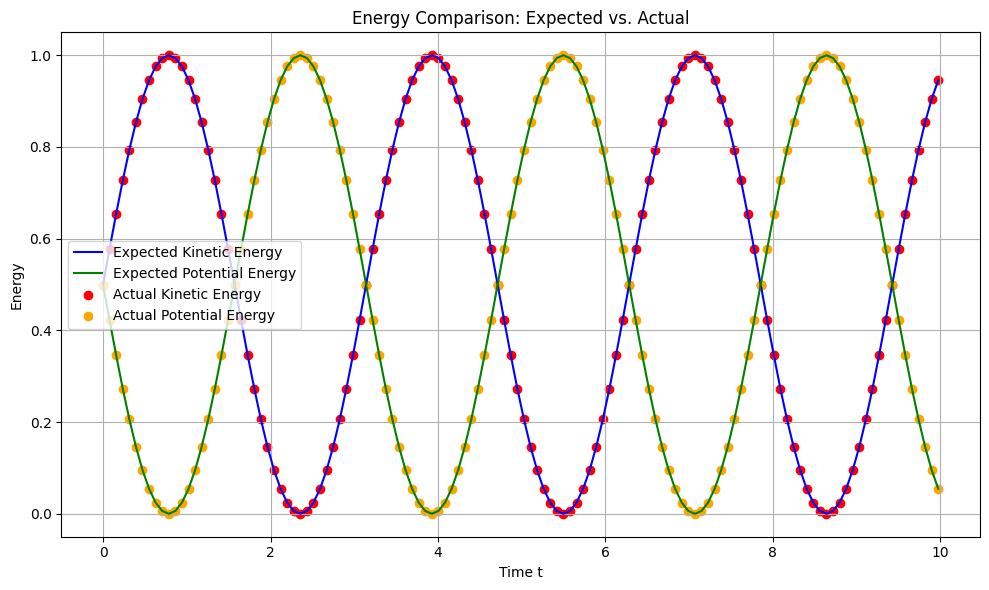

In [45]:
t_values = [i * dt for i in range(round(t_end / dt) + 1)]
def lookup(t, base):
    idx = round((t % t0) / dt)
    return base[idx]

y1      = [lookup(t, y)      for t in t_values]
y_dash1 = [lookup(t, y_dash) for t in t_values]

# Expected energies calculated from the formulas
y_values = [np.sin(t) + np.cos(t) for t in t_values]
ydash_values = [np.cos(t) - np.sin(t) for t in t_values]

kinetic_expected = [(y**2) / 2 for y in y_values]
potential_expected = [(ydash**2) / 2 for ydash in ydash_values]


# Actual energies calculated from algorithm outputs:
kinetic_actual = [(y_val**2) / 2 for y_val in y1]
potential_actual = [(ydash_val**2) / 2 for ydash_val in y_dash1]


plt.figure(figsize=(10, 6))


plt.plot(
    t_values,
    kinetic_expected,
    label="Expected Kinetic Energy",
    color="blue",
    linestyle="-",
)
plt.plot(
    t_values,
    potential_expected,
    label="Expected Potential Energy",
    color="green",
    linestyle="-",
)


plt.scatter(
    t_values, kinetic_actual, label="Actual Kinetic Energy", color="red", marker="o"
)
plt.scatter(
    t_values,
    potential_actual,
    label="Actual Potential Energy",
    color="orange",
    marker="o",
)


plt.xlabel("Time t")
plt.ylabel("Energy")
plt.title("Energy Comparison: Expected vs. Actual")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
results = [
    [
        i * dt,
        kinetic_expected[i],
        kinetic_actual[i],
        potential_expected[i],
        potential_actual[i],
    ]
    for i in range(round(t_end / dt) + 1)
]
table = tabulate(
    results,
    headers=[
        "t",
        "Kinetic expected",
        "Kinetic actual",
        "Potential expected",
        "Potential actual)",
    ],
    numalign="center",
    tablefmt="github",
)
print(table)

error_bound_potential = [
    100 * np.abs(a - e) / a for a, e in zip(potential_expected, potential_actual)
    if a > 1e-6
]
error_bound_kinetic = [
    100 * np.abs(a - e) / a for a, e in zip(kinetic_expected, kinetic_actual)
    if a > 1e-6
]

print("\n\nkinetic accuracy (Mean): ", 100 - np.mean(error_bound_kinetic), "%")
print("potential accuracy (Mean): ", 100 - np.mean(error_bound_potential), "%")

|     t     |  Kinetic expected  |  Kinetic actual  |  Potential expected  |  Potential actual)  |
|-----------|--------------------|------------------|----------------------|---------------------|
|     0     |        0.5         |       0.5        |         0.5          |         0.5         |
| 0.0785398 |      0.578217      |     0.578217     |       0.421783       |      0.421783       |
|  0.15708  |      0.654508      |     0.654508     |       0.345492       |      0.345492       |
| 0.235619  |      0.726995      |     0.726995     |       0.273005       |      0.273005       |
| 0.314159  |      0.793893      |     0.793893     |       0.206107       |      0.206107       |
| 0.392699  |      0.853553      |     0.853553     |       0.146447       |      0.146447       |
| 0.471239  |      0.904508      |     0.904508     |      0.0954915       |      0.0954915      |
| 0.549779  |      0.945503      |     0.945503     |      0.0544967       |      0.0544967      |
| 0.628319